<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/ReinforcementLearningAndDecisionMaking/ReinforcementLearningAndDecisionMaking/Multi_Asset_RL_Portfolio_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Dirichlet

In [2]:
# --- CONFIGURATION ---
TICKERS = ["NVDA", "GLD", "BTC-USD", "USDT-USD"] # Tech, Gold, Crypto, Cash Proxy
START_DATE = "2020-01-01"
END_DATE = "2024-01-01"
WINDOW_SIZE = 30 # Lookback window
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
def get_multi_asset_data(tickers):
    print(f"⬇️ Downloading aligned data for: {tickers}...")
    data_dict = {}

    # 1. Download & Align
    raw_data = yf.download(tickers, start=START_DATE, end=END_DATE, progress=False)['Close']
    raw_data.ffill(inplace=True)
    raw_data.bfill(inplace=True)

    # 2. Process each ticker
    processed_frames = []
    for t in tickers:
        df = pd.DataFrame(raw_data[t])
        df.columns = ['Close']

        # Returns
        df['Ret'] = df['Close'].pct_change().fillna(0)

        # Volatility (Risk)
        df['Vol'] = df['Ret'].rolling(20).std().fillna(0)

        # RSI (Momentum)
        delta = df['Close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
        rs = gain / (loss + 1e-7)
        df['RSI'] = 100 - (100 / (1 + rs))
        df['RSI'] = df['RSI'].fillna(50) / 100.0 # Normalize 0-1

        # Normalized Price (for neural net stability)
        df['Norm_Close'] = df['Close'] / df['Close'].iloc[0]

        processed_frames.append(df[['Ret', 'Vol', 'RSI', 'Norm_Close']].values)

    # Shape: (Time, Assets, Features)
    # We stack them so we have a 3D Tensor
    data_tensor = np.stack(processed_frames, axis=1)

    # Calculate Covariance Matrix History (Optional but good for Pro agents)
    # For this tutorial, we will rely on the agent inferring correlation from raw history

    return data_tensor, raw_data

data_tensor, price_df = get_multi_asset_data(TICKERS)
N_ASSETS = len(TICKERS)
N_FEATURES = data_tensor.shape[2]
print(f"✅ Data Shape: {data_tensor.shape} (Time, Assets, Features)")

⬇️ Downloading aligned data for: ['NVDA', 'GLD', 'BTC-USD', 'USDT-USD']...


/tmp/ipython-input-705698734.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(tickers, start=START_DATE, end=END_DATE, progress=False)['Close']


✅ Data Shape: (1461, 4, 4) (Time, Assets, Features)


In [4]:
class PortfolioEnv(gym.Env):
    def __init__(self, data_tensor):
        super(PortfolioEnv, self).__init__()
        self.data = data_tensor
        self.n_assets = data_tensor.shape[1]

        # Action: Vector of weights summing to 1.0
        self.action_space = spaces.Box(low=0, high=1, shape=(self.n_assets,), dtype=np.float32)

        # Observation: The historical window for ALL assets + current weights
        # Shape: (Window, Assets, Features) flattened or kept structured
        # For simplicity, we flatten: Window * Assets * Features + Current Weights
        self.obs_shape = (WINDOW_SIZE * self.n_assets * N_FEATURES) + self.n_assets
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.obs_shape,), dtype=np.float32)

    def reset(self, seed=None):
        self.current_step = WINDOW_SIZE
        # Start with Equal Weights
        self.weights = np.ones(self.n_assets) / self.n_assets
        self.portfolio_value = 10000.0
        self.history = []
        return self._get_obs(), {}

    def _get_obs(self):
        # 1. Market Data Window
        window = self.data[self.current_step-WINDOW_SIZE : self.current_step]
        flat_window = window.flatten()

        # 2. Append Current Portfolio Weights (Agent needs to know what it holds)
        obs = np.concatenate([flat_window, self.weights])
        return obs.astype(np.float32)

    def step(self, action):
        # Action is the NEW target weights
        # We normalize them to ensure sum=1 (Softmax safety)
        weights = np.exp(action) / np.sum(np.exp(action))
        self.weights = weights

        # 1. Calculate Portfolio Return
        # Look ahead one step to see what happened
        next_step_rets = self.data[self.current_step, :, 0] # Index 0 is 'Ret'

        # Portfolio Return = dot product of weights and asset returns
        port_ret = np.sum(weights * next_step_rets)

        # 2. Update Value
        self.portfolio_value *= (1 + port_ret)
        self.history.append(port_ret)

        # 3. Reward: Sharpe Ratio (Risk-Adjusted)
        # We use a rolling Sharpe reward
        reward = port_ret * 100 # Base reward
        if len(self.history) > 30:
            hist_window = np.array(self.history[-30:])
            sharpe = hist_window.mean() / (hist_window.std() + 1e-6)
            reward += sharpe * 0.1 # Bonus for stability

        self.current_step += 1
        done = self.current_step >= len(self.data) - 1

        return self._get_obs(), reward, done, False, {'val': self.portfolio_value}

In [5]:
class PortfolioAgent:
    def __init__(self, input_dim, n_assets):
        self.gamma = 0.99
        self.clip = 0.2
        self.n_assets = n_assets

        # Actor: Outputs logits for each asset
        self.actor = nn.Sequential(
            nn.Linear(input_dim, 256), nn.Tanh(),
            nn.Linear(256, 128), nn.Tanh(),
            nn.Linear(128, n_assets) # Outputs raw logits
        ).float().to(DEVICE)

        # Critic: Estimates Value of state
        self.critic = nn.Sequential(
            nn.Linear(input_dim, 256), nn.Tanh(),
            nn.Linear(256, 128), nn.Tanh(),
            nn.Linear(128, 1)
        ).float().to(DEVICE)

        self.optimizer = optim.Adam(list(self.actor.parameters()) + list(self.critic.parameters()), lr=0.0001)
        self.memory = []

    def select_action(self, state):
        state = torch.FloatTensor(state).flatten().unsqueeze(0).to(DEVICE)
        logits = self.actor(state)

        # Exploration: Add noise to logits
        # We treat these logits as parameters for a Categorical-like selection
        # But here we just return the logits directly for the Env to Softmax
        # To make it stochastic (exploration), we sample from a Normal dist around the logits
        dist = torch.distributions.Normal(logits, 0.5) # 0.5 is exploration noise
        action = dist.sample()

        log_prob = dist.log_prob(action).sum(dim=-1)
        return action.cpu().numpy().flatten(), log_prob.item()

    def record(self, s, a, lp, r, d):
        self.memory.append((s, a, lp, r, d))

    def learn(self):
        if not self.memory: return

        # Unpack memory
        s, a, lp, r, d = zip(*self.memory)
        states = torch.tensor(np.array(s), dtype=torch.float32).to(DEVICE)
        actions = torch.tensor(np.array(a), dtype=torch.float32).to(DEVICE)
        old_logprobs = torch.tensor(np.array(lp), dtype=torch.float32).to(DEVICE)

        # Calculate Returns
        returns = []
        G = 0
        for reward in reversed(r):
            G = reward + 0.99 * G
            returns.insert(0, G)
        returns = torch.tensor(returns, dtype=torch.float32).to(DEVICE)
        returns = (returns - returns.mean()) / (returns.std() + 1e-6)

        # PPO Update
        for _ in range(5):
            # Recalculate component
            logits = self.actor(states)
            dist = torch.distributions.Normal(logits, 0.5)

            new_logprobs = dist.log_prob(actions).sum(dim=-1)
            ratio = torch.exp(new_logprobs - old_logprobs)

            values = self.critic(states).squeeze()
            advantage = returns - values.detach()

            surr1 = ratio * advantage
            surr2 = torch.clamp(ratio, 0.8, 1.2) * advantage

            loss = -torch.min(surr1, surr2) + 0.5 * nn.MSELoss()(values, returns)

            self.optimizer.zero_grad()
            loss.mean().backward()
            torch.nn.utils.clip_grad_norm_(self.actor.parameters(), 0.5)
            self.optimizer.step()

        self.memory = []

In [6]:
print("🚀 Launching Multi-Asset Training...")

env = PortfolioEnv(data_tensor)
agent = PortfolioAgent(input_dim=env.obs_shape, n_assets=N_ASSETS)

scores = []
allocations = [] # To track how the agent shifts money

# 1. TRAIN
for ep in range(50):
    s, _ = env.reset()
    done = False
    ep_score = 0

    while not done:
        a, lp = agent.select_action(s)
        ns, r, done, _, info = env.step(a)

        agent.record(s, a, lp, r, done)
        s = ns
        ep_score += r

        # Learn every month (approx 20 trading days)
        if env.current_step % 20 == 0:
            agent.learn()

    scores.append(info['val'])
    print(f"Ep {ep+1}: Final Portfolio Value ${info['val']:.0f}")

🚀 Launching Multi-Asset Training...
Ep 1: Final Portfolio Value $27348
Ep 2: Final Portfolio Value $29979
Ep 3: Final Portfolio Value $23908
Ep 4: Final Portfolio Value $36623
Ep 5: Final Portfolio Value $25820
Ep 6: Final Portfolio Value $31776
Ep 7: Final Portfolio Value $29519
Ep 8: Final Portfolio Value $33439
Ep 9: Final Portfolio Value $62797
Ep 10: Final Portfolio Value $48038
Ep 11: Final Portfolio Value $61197
Ep 12: Final Portfolio Value $21849
Ep 13: Final Portfolio Value $48233
Ep 14: Final Portfolio Value $29543
Ep 15: Final Portfolio Value $27859
Ep 16: Final Portfolio Value $18834
Ep 17: Final Portfolio Value $16166
Ep 18: Final Portfolio Value $17790
Ep 19: Final Portfolio Value $16189
Ep 20: Final Portfolio Value $14730
Ep 21: Final Portfolio Value $19912
Ep 22: Final Portfolio Value $20234
Ep 23: Final Portfolio Value $26945
Ep 24: Final Portfolio Value $22581
Ep 25: Final Portfolio Value $28568
Ep 26: Final Portfolio Value $16684
Ep 27: Final Portfolio Value $20547
E

In [7]:
# 2. AUDIT (Deterministic Backtest)
print("\n📊 Running Backtest Audit...")
test_env = PortfolioEnv(data_tensor)
s, _ = test_env.reset()
done = False
history_val = []
history_weights = []

while not done:
    with torch.no_grad():
        s_t = torch.FloatTensor(s).unsqueeze(0).to(DEVICE)
        logits = agent.actor(s_t).cpu().numpy().flatten()
        # Deterministic Choice: Just take the logits directly

    s, _, done, _, info = test_env.step(logits)
    history_val.append(info['val'])
    history_weights.append(test_env.weights)


📊 Running Backtest Audit...


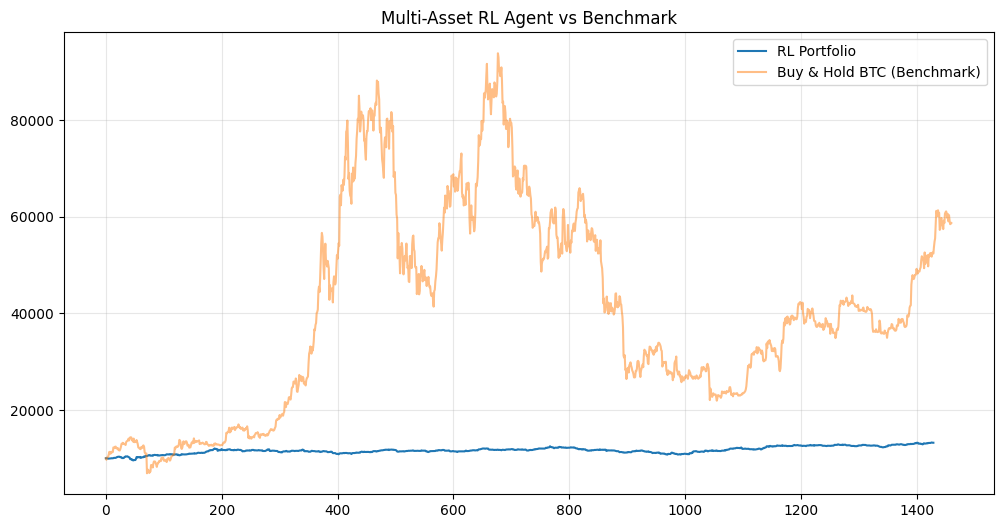

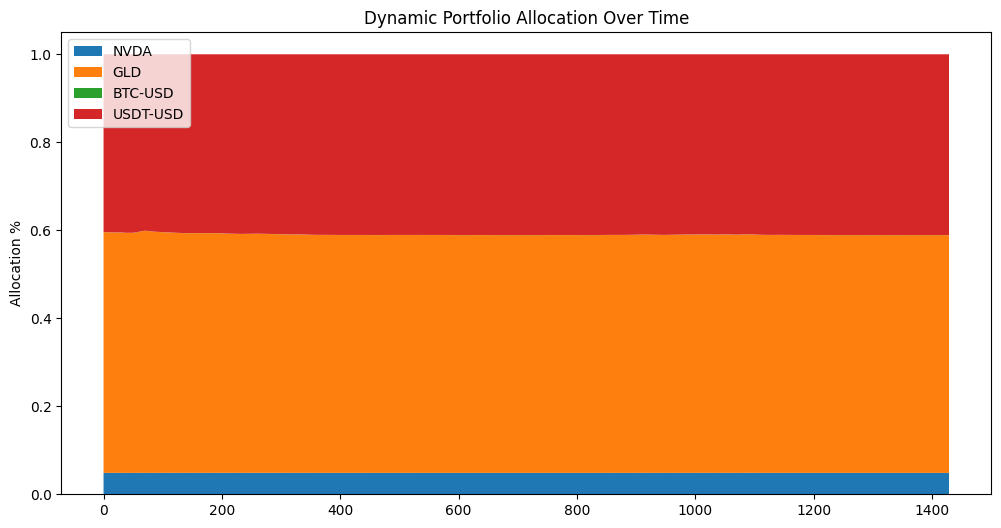

In [8]:
# 3. PLOTS
plt.figure(figsize=(12, 6))
plt.plot(history_val, label="RL Portfolio")
plt.plot(price_df['BTC-USD'].values / price_df['BTC-USD'].iloc[0] * 10000, label="Buy & Hold BTC (Benchmark)", alpha=0.5)
plt.title("Multi-Asset RL Agent vs Benchmark")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Stackplot of Allocation
weights_np = np.array(history_weights)
plt.figure(figsize=(12, 6))
plt.stackplot(range(len(weights_np)), weights_np.T, labels=TICKERS)
plt.title("Dynamic Portfolio Allocation Over Time")
plt.legend(loc='upper left')
plt.ylabel("Allocation %")
plt.show()

In [9]:
# --- BLOCK 8: MULTI-ASSET METRICS ---

# Convert history to DataFrame for easy analysis
portfolio_curve = pd.Series(history_val)
returns = portfolio_curve.pct_change().dropna()

# 1. Total Return & CAGR
total_ret = (portfolio_curve.iloc[-1] / portfolio_curve.iloc[0]) - 1
# Assuming 252 trading days for multi-asset (mix of crypto/stocks usually defaults to business days)
cagr = (portfolio_curve.iloc[-1] / portfolio_curve.iloc[0]) ** (252/len(portfolio_curve)) - 1

# 2. Volatility
vol = returns.std() * np.sqrt(252)

# 3. Sharpe Ratio
sharpe = (returns.mean() / returns.std()) * np.sqrt(252) if vol > 0 else 0

# 4. Sortino Ratio (Downside Risk)
neg_ret = returns[returns < 0]
downside_std = neg_ret.std() * np.sqrt(252) if len(neg_ret) > 0 else 1.0
sortino = (returns.mean() * 252) / downside_std if downside_std > 0 else 0

# 5. Max Drawdown
cum_ret = (1 + returns).cumprod()
peak = cum_ret.cummax()
dd = (cum_ret - peak) / peak
max_dd = dd.min()

# 6. Correlation with Bitcoin (Did we decouple?)
# We need to align the lengths perfectly
btc_curve = price_df['BTC-USD'].iloc[:len(returns)].pct_change().dropna()
# Ensure alignment
min_len = min(len(returns), len(btc_curve))
correlation = returns.iloc[-min_len:].corr(btc_curve.iloc[-min_len:])

# --- DISPLAY ---
metrics_data = {
    "Metric": ["Total Return", "CAGR", "Sharpe Ratio", "Sortino Ratio", "Volatility", "Max Drawdown", "Corr with BTC"],
    "Value": [
        f"{total_ret*100:.1f}%",
        f"{cagr*100:.1f}%",
        f"{sharpe:.2f}",
        f"{sortino:.2f}",
        f"{vol*100:.1f}%",
        f"{max_dd*100:.1f}%",
        f"{correlation:.2f}"
    ]
}

print("\n" + "="*40)
print(f"📊 MULTI-ASSET AGENT PERFORMANCE")
print("="*40)
metrics_df = pd.DataFrame(metrics_data)
print(metrics_df.to_string(index=False))
print("="*40)


📊 MULTI-ASSET AGENT PERFORMANCE
       Metric  Value
 Total Return  32.1%
         CAGR   5.0%
 Sharpe Ratio   0.67
Sortino Ratio   0.83
   Volatility   7.8%
 Max Drawdown -13.8%
Corr with BTC    nan
